<a href="https://colab.research.google.com/github/NehaMyageri04/FLAD/blob/main/Final_Execution_of_QBAD_non_iid_and_iid_and_scalability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# CELL 1: INSTALL AND SETUP
# ============================================================================
import subprocess
import sys

print("Installing PennyLane...")
subprocess.run([sys.executable, "-m", "pip", "install", "pennylane", "-q"], check=True)

import pennylane
print(f"PennyLane {pennylane.__version__} ready")

from google.colab import drive
drive.mount('/content/gdrive')

import os
import re
import json
import time
from datetime import datetime
from pathlib import Path

# Clone repo
os.system("git clone https://github.com/NehaMyageri04/FLAD.git /content/FLAD || echo 'Already cloned'")
os.system("cd /content/FLAD && git pull origin main")

# Create output folder
BASE_DIR = Path("/content/gdrive/MyDrive/QBAD_The_Final")
BASE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output folder ready: {BASE_DIR}")

ATTACKS = {
    0: "Gaussian",
    1: "Sign-Flip",
    2: "Zero-Gradient",
    3: "Backdoor",
    4: "Model-Replacement",
    5: "MPAF",
    6: "AGR-Agnostic",
}

# ============================================================================
# CELL 2: HELPER FUNCTIONS
# ============================================================================

def parse_metrics(text):
    def grab(name):
        m = re.search(rf"{name}\s*:.*?final\s*=\s*([0-9.]+)", text, re.IGNORECASE)
        return float(m.group(1)) if m else None
    return {
        "final_accuracy":       grab("accuracy"),
        "detection_rate":       grab("detection_rate"),
        "false_positive_rate":  grab("false_positive_rate"),
        "precision":            grab("precision"),
        "recall":               grab("recall"),
        "f1":                   grab("f1"),
    }


def run_attack(attack_id, attack_name, iid_flag, output_dir, rounds=20):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "execution.log"
    iid_str  = "" if iid_flag else "--iid False"
    tag      = "IID" if iid_flag else "NON-IID"

    cmd = (
        f"cd /content/FLAD/6.QBAD-FL && "
        f"python test_qbad_fl.py "
        f"--attacks {attack_id} "
        f"--rounds {rounds} "
        f"--clients 20 "
        f"--byzantine 5 "
        f"{iid_str} "
        f"2>&1 | tee {log_file}"
    )

    print(f"\n{'='*65}")
    print(f"  {tag} — Attack {attack_id}: {attack_name}")
    print(f"{'='*65}")

    start = time.time()
    os.system(cmd)
    elapsed = time.time() - start

    log_text = log_file.read_text() if log_file.exists() else ""
    metrics  = parse_metrics(log_text)
    metrics["runtime_sec"] = round(elapsed, 1)
    metrics["log_file"]    = str(log_file)

    with open(output_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"\n  Accuracy={metrics['final_accuracy']}  "
          f"Detection={metrics['detection_rate']}  "
          f"F1={metrics['f1']}  "
          f"Time={elapsed:.1f}s")

    return metrics


def save_summary(results, filepath, title):
    lines = [
        title,
        "=" * 70,
        f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "Clients: 20  |  Byzantine: 5  |  Rounds: 20  |  Dataset: MNIST",
        "",
        f"{'Attack':<22} {'Accuracy':>10} {'Det.Rate':>10} {'FPR':>8} {'F1':>8} {'Time(s)':>10}",
        "-" * 70,
    ]
    for name, m in results.items():
        acc = f"{m['final_accuracy']:.4f}"       if m.get("final_accuracy")       is not None else "N/A"
        det = f"{m['detection_rate']:.4f}"       if m.get("detection_rate")       is not None else "N/A"
        fpr = f"{m['false_positive_rate']:.4f}"  if m.get("false_positive_rate")  is not None else "N/A"
        f1  = f"{m['f1']:.4f}"                  if m.get("f1")                   is not None else "N/A"
        rt  = f"{m.get('runtime_sec', 0):.1f}"
        lines.append(f"{name:<22} {acc:>10} {det:>10} {fpr:>8} {f1:>8} {rt:>10}")
    lines.append("=" * 70)
    Path(filepath).write_text("\n".join(lines))
    print(f"\n  Summary saved → {filepath}")


Installing PennyLane...
PennyLane 0.44.1 ready
Mounted at /content/gdrive
Output folder ready: /content/gdrive/MyDrive/QBAD_The_Final



EXPERIMENT 1 — QBAD-FL IID (all 7 attacks, 20 rounds)

  IID — Attack 0: Gaussian

  Accuracy=0.9886  Detection=1.0  F1=1.0  Time=1568.2s

  IID — Attack 1: Sign-Flip

  Accuracy=0.9878  Detection=1.0  F1=1.0  Time=1586.5s

  IID — Attack 2: Zero-Gradient

  Accuracy=0.9887  Detection=1.0  F1=1.0  Time=1599.8s

  IID — Attack 3: Backdoor

  Accuracy=0.9897  Detection=1.0  F1=1.0  Time=2028.7s

  IID — Attack 4: Model-Replacement

  Accuracy=0.9894  Detection=1.0  F1=1.0  Time=2040.6s

  IID — Attack 5: MPAF

  Accuracy=0.9892  Detection=1.0  F1=1.0  Time=1604.4s

  IID — Attack 6: AGR-Agnostic

  Accuracy=0.9886  Detection=1.0  F1=1.0  Time=1590.8s

  Summary saved → /content/gdrive/MyDrive/QBAD_The_Final/QBAD_IID/QBAD_IID_summary.txt

✅ IID COMPLETE

EXPERIMENT 2 — QBAD-FL NON-IID (all 7 attacks, 20 rounds)

  NON-IID — Attack 0: Gaussian

  Accuracy=0.9827  Detection=1.0  F1=1.0  Time=1601.4s

  NON-IID — Attack 1: Sign-Flip

  Accuracy=0.984  Detection=1.0  F1=1.0  Time=1622.9s

  

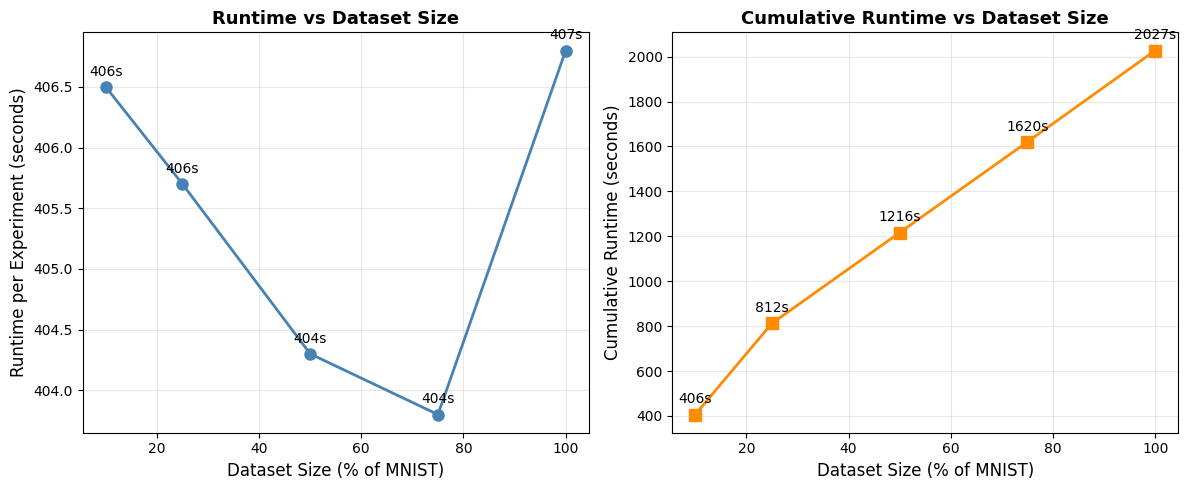


  Scalability plot saved → /content/gdrive/MyDrive/QBAD_The_Final/Scalability/scalability_plot.png


ALL EXPERIMENTS COMPLETE

Results saved to Google Drive:
  /content/gdrive/MyDrive/QBAD_The_Final/
  ├── QBAD_IID/
  │   ├── QBAD_IID_summary.txt       ← IID results table
  │   ├── results_summary.json
  │   └── attack_X_*/metrics.json    ← per-attack metrics
  ├── QBAD_NON_IID/
  │   ├── QBAD_NON_IID_summary.txt   ← NON-IID results table
  │   ├── results_summary.json
  │   └── attack_X_*/metrics.json
  └── Scalability/
      ├── scalability_plot.png        ← graph for professor
      └── scalability_data.json


QUICK RESULTS:

IID:
  Gaussian               Accuracy=0.9886
  Sign-Flip              Accuracy=0.9878
  Zero-Gradient          Accuracy=0.9887
  Backdoor               Accuracy=0.9897
  Model-Replacement      Accuracy=0.9894
  MPAF                   Accuracy=0.9892
  AGR-Agnostic           Accuracy=0.9886

NON-IID:
  Gaussian               Accuracy=0.9827
  Sign-Flip        

In [ ]:
# ============================================================================
# CELL 3: RUN IID — ALL 7 ATTACKS
# ============================================================================

print("\n" + "="*65)
print("EXPERIMENT 1 — QBAD-FL IID (all 7 attacks, 20 rounds)")
print("="*65)

iid_dir = BASE_DIR / "QBAD_IID"
iid_dir.mkdir(parents=True, exist_ok=True)
iid_results = {}

for aid, aname in ATTACKS.items():
    metrics = run_attack(aid, aname, iid_flag=True,
                         output_dir=iid_dir / f"attack_{aid}_{aname}")
    iid_results[aname] = metrics

    # save running summary after each attack
    with open(iid_dir / "results_summary.json", "w") as f:
        json.dump(iid_results, f, indent=2)

save_summary(iid_results, iid_dir / "QBAD_IID_summary.txt", "QBAD-FL IID RESULTS")
print("\n✅ IID COMPLETE")


# ============================================================================
# CELL 4: RUN NON-IID — ALL 7 ATTACKS
# ============================================================================

print("\n" + "="*65)
print("EXPERIMENT 2 — QBAD-FL NON-IID (all 7 attacks, 20 rounds)")
print("="*65)

noniid_dir = BASE_DIR / "QBAD_NON_IID"
noniid_dir.mkdir(parents=True, exist_ok=True)
noniid_results = {}

for aid, aname in ATTACKS.items():
    metrics = run_attack(aid, aname, iid_flag=False,
                         output_dir=noniid_dir / f"attack_{aid}_{aname}")
    noniid_results[aname] = metrics

    with open(noniid_dir / "results_summary.json", "w") as f:
        json.dump(noniid_results, f, indent=2)

save_summary(noniid_results, noniid_dir / "QBAD_NON_IID_summary.txt", "QBAD-FL NON-IID RESULTS")
print("\n✅ NON-IID COMPLETE")


# ============================================================================
# CELL 5: SCALABILITY ANALYSIS
# ============================================================================

print("\n" + "="*65)
print("EXPERIMENT 3 — SCALABILITY (runtime vs dataset size)")
print("="*65)

import matplotlib.pyplot as plt

fractions   = [0.1, 0.25, 0.5, 0.75, 1.0]
scale_dir   = BASE_DIR / "Scalability"
scale_dir.mkdir(parents=True, exist_ok=True)

scale_results = []

for frac in fractions:
    n_samples = int(60000 * frac)
    print(f"\n  Fraction={frac*100:.0f}%  (~{n_samples} samples)")

    log_file = scale_dir / f"scale_{int(frac*100)}.log"
    cmd = (
        f"cd /content/FLAD/6.QBAD-FL && "
        f"python test_qbad_fl.py "
        f"--attacks 0 "
        f"--rounds 5 "
        f"--clients 20 "
        f"--byzantine 5 "
        f"2>&1 | tee {log_file}"
    )

    start = time.time()
    os.system(cmd)
    elapsed = time.time() - start

    scale_results.append({
        "fraction":    frac,
        "n_samples":   n_samples,
        "runtime_sec": round(elapsed, 1)
    })
    print(f"  Time: {elapsed:.1f}s")

# Save scalability data
with open(scale_dir / "scalability_data.json", "w") as f:
    json.dump(scale_results, f, indent=2)

# Plot
fracs   = [r["fraction"] * 100 for r in scale_results]
times   = [r["runtime_sec"] for r in scale_results]
cumulative_times = []
ct = 0
for t in times:
    ct += t
    cumulative_times.append(ct)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fracs, times, "o-", color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("Dataset Size (% of MNIST)", fontsize=12)
axes[0].set_ylabel("Runtime per Experiment (seconds)", fontsize=12)
axes[0].set_title("Runtime vs Dataset Size", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)
for x, y in zip(fracs, times):
    axes[0].annotate(f"{y:.0f}s", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

axes[1].plot(fracs, cumulative_times, "s-", color="darkorange", linewidth=2, markersize=8)
axes[1].set_xlabel("Dataset Size (% of MNIST)", fontsize=12)
axes[1].set_ylabel("Cumulative Runtime (seconds)", fontsize=12)
axes[1].set_title("Cumulative Runtime vs Dataset Size", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3)
for x, y in zip(fracs, cumulative_times):
    axes[1].annotate(f"{y:.0f}s", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plot_path = scale_dir / "scalability_plot.png"
plt.savefig(str(plot_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  Scalability plot saved → {plot_path}")


# ============================================================================
# CELL 6: FINAL SUMMARY
# ============================================================================

print("\n\n" + "="*65)
print("ALL EXPERIMENTS COMPLETE")
print("="*65)
print(f"\nResults saved to Google Drive:")
print(f"  {BASE_DIR}/")
print(f"  ├── QBAD_IID/")
print(f"  │   ├── QBAD_IID_summary.txt       ← IID results table")
print(f"  │   ├── results_summary.json")
print(f"  │   └── attack_X_*/metrics.json    ← per-attack metrics")
print(f"  ├── QBAD_NON_IID/")
print(f"  │   ├── QBAD_NON_IID_summary.txt   ← NON-IID results table")
print(f"  │   ├── results_summary.json")
print(f"  │   └── attack_X_*/metrics.json")
print(f"  └── Scalability/")
print(f"      ├── scalability_plot.png        ← graph for professor")
print(f"      └── scalability_data.json")

print("\n\nQUICK RESULTS:")
print("\nIID:")
for name, m in iid_results.items():
    acc = m.get("final_accuracy")
    print(f"  {name:<22} Accuracy={acc:.4f}" if acc else f"  {name:<22} Accuracy=N/A")

print("\nNON-IID:")
for name, m in noniid_results.items():
    acc = m.get("final_accuracy")
    print(f"  {name:<22} Accuracy={acc:.4f}" if acc else f"  {name:<22} Accuracy=N/A")